# Анализ исходных данных, ручное обучение моделей и подготовка отчетов

Практический notebook для manual workflow в ml-server. Он дополняет Stage 0-6 documentation и позволяет:

- проверить качество исходных данных до обучения;
- провести exploratory data analysis;
- вручную обучить несколько кандидатов;
- сравнить алгоритмы по общей схеме;
- собрать human-readable report bundle.

> Важно: notebook не зависит от не реализованного `POST /train` и предназначен для offline/manual workflow.

## 0. Scope и expected outputs

На выходе notebook должен дать:

- summary по данным;
- metrics по baseline и model candidates;
- recommendation по выбору алгоритма;
- optional export файлов для дальнейшего review.

Связанные документы:

- Stage 0: readiness и pre-flight checks;
- Stage 4: manual training patterns;
- Stage 5: canonical metrics and artifact layout.

In [ ]:
from __future__ import annotations

import hashlib
import io
import json
import math
import re
import shutil
import time
from dataclasses import dataclass, asdict, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
except ImportError:
    xgb = None

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

NOTEBOOK_ROOT = '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/training_workspace'
PROJECT_ROOT = Path(NOTEBOOK_ROOT).parents[2] if 'docs' in Path(NOTEBOOK_ROOT).parts else Path(NOTEBOOK_ROOT)
REPORTS_DIR = Path(NOTEBOOK_ROOT) / 'manual_reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

def _sanitize_slug(value: str) -> str:
    slug = re.sub(r'[^A-Za-z0-9_.-]+', '_', value.strip('/'))
    return slug[:180] if len(slug) > 180 else slug

print(f'NOTEBOOK_ROOT={NOTEBOOK_ROOT}')
print(f'PROJECT_ROOT={PROJECT_ROOT}')
print(f'REPORTS_DIR={REPORTS_DIR}')
print(f'xgboost_available={xgb is not None}')

NOTEBOOK_ROOT=/Users/rustamkrikbayev/Documents/projects/forecast/local/training
PROJECT_ROOT=/Users/rustamkrikbayev/Documents/projects/forecast/local/training
REPORTS_DIR=/Users/rustamkrikbayev/Documents/projects/forecast/local/training/manual_reports
xgboost_available=True


In [208]:
# ── Выбор модели из batch collection ──────────────────────────────────────────
import subprocess
import sys

BATCH_LOCAL_DIR   = PROJECT_ROOT / 'models_enabled'
BATCH_MODELS_CSV  = BATCH_LOCAL_DIR / 'model_list__models__short.csv'
BATCH_INPUTS_CSV  = BATCH_LOCAL_DIR / 'model_list__inputs.csv'
BATCH_OUTPUT_ROOT = BATCH_LOCAL_DIR / 'model_data_collection'
BATCH_SUMMARY     = BATCH_OUTPUT_ROOT / 'batch_summary.json'


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'ml-server').exists() and (candidate / 'ml-server' / 'scripts').exists():
            return candidate
    return start


def _generate_batch_summary_if_possible() -> None:
    repo_root = _find_repo_root(Path(NOTEBOOK_ROOT))
    script_path = repo_root / 'ml-server' / 'scripts' / 'batch_model_data_collection.py'
    python_path = repo_root / 'ml-server' / '.venv' / 'bin' / 'python'

    if not script_path.exists():
        print(f'WARNING: batch script not found: {script_path}')
        return
    if not BATCH_MODELS_CSV.exists():
        print(f'WARNING: models csv not found: {BATCH_MODELS_CSV}')
        return

    py_exec = str(python_path) if python_path.exists() else sys.executable
    cmd = [
        py_exec,
        str(script_path),
        '--models-csv',
        str(BATCH_MODELS_CSV),
        '--inputs-csv',
        str(BATCH_INPUTS_CSV),
        '--output-root',
        str(BATCH_OUTPUT_ROOT),
        '--source-mode',
        'stub',
    ]

    print('Building batch summary before CSV read...')
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        tail = '\n'.join((proc.stderr or proc.stdout or '').splitlines()[-20:])
        raise RuntimeError(f'Failed to build batch_summary.json\n{tail}')

    tail = '\n'.join((proc.stdout or '').splitlines()[-10:])
    if tail:
        print(tail)


def _read_models_csv(path: Path) -> pd.DataFrame:
    probe = pd.read_csv(path, nrows=1)
    return pd.read_csv(path, sep=';') if len(probe.columns) <= 2 else pd.read_csv(path)


# Перед чтением CSV актуализируем batch_summary.json
_generate_batch_summary_if_possible()

# Читаем summary → словарь object_ref -> {status, reason}
_summary_status: dict[str, str] = {}
_summary_reason: dict[str, str] = {}
if BATCH_SUMMARY.exists():
    for _s in json.loads(BATCH_SUMMARY.read_text(encoding='utf-8')):
        _ref = str(_s.get('object_ref', ''))
        _summary_status[_ref] = str(_s.get('status', 'unknown'))
        _summary_reason[_ref] = str(_s.get('reason', ''))
else:
    print(f'WARNING: batch_summary.json not found: {BATCH_SUMMARY}')

_models = _read_models_csv(BATCH_MODELS_CSV)
_models['_slug']         = _models['object_ref'].astype(str).apply(_sanitize_slug)
_models['_status']       = _models['object_ref'].astype(str).map(_summary_status).fillna('not_in_summary')
_models['_reason']       = _models['object_ref'].astype(str).map(_summary_reason).fillna('')
_models['_train_parquet'] = _models['_slug'].apply(
    lambda s: BATCH_OUTPUT_ROOT / s / 'datasets' / 'train_snapshot.parquet'
)

_ready   = _models[_models['_status'] == 'ok'].reset_index(drop=True)
_skipped = _models[_models['_status'] != 'ok'].reset_index(drop=True)
print(f'Models found in CSV: {len(_models)}')
print(f'Content of _skipped: {_skipped[["_slug", "_status", "_reason"]].to_string(index=False)}')
print(f'Ready for training: {len(_ready)}')
display(_ready[['object_ref', 'onbject', 'type', 'output_range', '_status', '_slug']].to_string(index=False))

if not _skipped.empty:
    print(f'\nSkipped/failed ({len(_skipped)}):')
    display(_skipped[['object_ref', '_status', '_reason']].to_string(index=False))

if _ready.empty:
    raise RuntimeError('No models with status=ok in batch_summary.json. Run MODEL_DATA_COLLECTION first.')

# ── Выберите индекс модели в _ready (0 = первая) ─────────────────────────────
SELECTED_ROW_INDEX = 0

_row = _ready.iloc[SELECTED_ROW_INDEX]
SELECTED_OBJECT_REF   = str(_row['object_ref'])
SELECTED_TRAIN_PATH   = Path(str(_row['_train_parquet']))
SELECTED_OUTPUT_RANGE = int(_row['output_range'])

print(f'\nSelected [{SELECTED_ROW_INDEX}]: {SELECTED_OBJECT_REF}')
print(f'train_snapshot : {SELECTED_TRAIN_PATH}')
print(f'exists         : {SELECTED_TRAIN_PATH.exists()}')
print(f'output_range   : {SELECTED_OUTPUT_RANGE}')


Building batch summary before CSV read...
Models found in CSV: 4
Content of _skipped:                                             _slug _status              _reason
root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_elect skipped No historical inputs
Ready for training: 3


'                                                           object_ref     onbject  type  output_range _status                                                              _slug\n                   /root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_watt VostVet_VES power            36      ok                   root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt\n/root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt    @regions power            36      ok root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt\n       /root/FP/PROJECT/AKMOLA/@regions/Kokshetau/load/@models/P_watt    @regions power            36      ok        root_FP_PROJECT_AKMOLA_regions_Kokshetau_load_models_P_watt'


Skipped/failed (1):


'                                         object_ref _status              _reason\n/root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_elect skipped No historical inputs'


Selected [0]: /root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_watt
train_snapshot : /Users/rustamkrikbayev/Documents/projects/forecast/local/training/models_enabled/model_data_collection/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/datasets/train_snapshot.parquet
exists         : True
output_range   : 36


## 1. Конфигурация manual workflow

Укажите источник данных, параметры временного ряда и активные кандидаты моделей.

In [227]:
@dataclass
class TrainingNotebookConfig:
    dataset_path: Path
    dataset_format: str = 'parquet'
    timestamp_column: str = 'timestamp'
    target_column: str = 'value'
    freq: str = 'H'
    train_ratio: float = 0.7
    validation_ratio: float = 0.15
    forecast_horizon: int = 24
    create_xgb_features: bool = True
    active_candidates: tuple[str, ...] = ('naive_last', 'prophet', 'xgboost')
    xgb_params: dict[str, Any] | None = None
    prophet_params: dict[str, Any] | None = None

    # Unified model storage root (single structure for offline train + runtime cache).
    model_store_root: Path | None = None
    bundle_output_dir: Path | None = None

    # MLflow workflow settings.
    mlflow_enabled: bool = False
    mlflow_tracking_uri: str | None = None
    mlflow_run_name_prefix: str = 'manual_workflow'
    object_reference: str = '/MANUAL/NOTEBOOK/OBJECT'

    # Derive MLflow names and local layout from object_reference/model_id.
    mlflow_experiment_name: str = field(default='', init=False)
    mlflow_model_registry_name: str = field(default='', init=False)
    model_id: str = field(default='', init=False)
    model_home_dir: Path = field(default=Path('.'), init=False)
    training_artifacts_dir: Path = field(default=Path('.'), init=False)
    training_reports_dir: Path = field(default=Path('.'), init=False)
    runtime_cache_dir: Path = field(default=Path('.'), init=False)

    # Dataset snapshot settings.
    dataset_snapshot_enabled: bool = True
    feature_schema_version: str = '1'

    def __post_init__(self) -> None:
        repo_root = _find_repo_root(Path(NOTEBOOK_ROOT))
        if self.model_store_root is None:
            self.model_store_root = repo_root / 'local' / 'models'

        self.model_id = _sanitize_slug(str(self.object_reference))
        self.mlflow_experiment_name = str(self.object_reference)
        self.mlflow_model_registry_name = self.model_id

        self.model_home_dir = Path(self.model_store_root) / self.model_id
        self.training_artifacts_dir = self.model_home_dir / 'training'
        self.training_reports_dir = self.training_artifacts_dir / 'reports'
        self.runtime_cache_dir = self.model_home_dir / 'runtime_cache'

        if self.bundle_output_dir is None:
            self.bundle_output_dir = self.training_artifacts_dir / 'bundle_export'

        for path in (self.model_home_dir, self.training_artifacts_dir, self.training_reports_dir, self.runtime_cache_dir, Path(self.bundle_output_dir)):
            path.mkdir(parents=True, exist_ok=True)


cfg = TrainingNotebookConfig(
    # ── данные из batch collection (заполняются ячейкой выбора модели выше) ────
    dataset_path=SELECTED_TRAIN_PATH,
    dataset_format='parquet',
    timestamp_column='ds',    # batch script пишет колонки ds / y
    target_column='y',
    forecast_horizon=SELECTED_OUTPUT_RANGE,
    object_reference=SELECTED_OBJECT_REF,
    # ── параметры обучения ───────────────────────────────────────────────────
    xgb_params={
        'objective': 'reg:squarederror',
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
    },
    prophet_params={
        'seasonality_mode': 'multiplicative',
        'changepoint_prior_scale': 0.05,
        'weekly_seasonality': True,
        'daily_seasonality': True,
    },
    mlflow_enabled=True,
    mlflow_tracking_uri='http://127.0.0.1:5050',
    mlflow_run_name_prefix='manual_training',
)

print(f'experiment name      : {cfg.mlflow_experiment_name}')
print(f'registry model_id    : {cfg.mlflow_model_registry_name}')
print(f'model_store_root     : {cfg.model_store_root}')
print(f'model_home_dir       : {cfg.model_home_dir}')
print(f'training_reports_dir : {cfg.training_reports_dir}')
print(f'runtime_cache_dir    : {cfg.runtime_cache_dir}')
asdict(cfg)

experiment name      : /root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_watt
registry model_id    : root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt
model_store_root     : /Users/rustamkrikbayev/Documents/projects/forecast/local/models
model_home_dir       : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt
training_reports_dir : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/reports
runtime_cache_dir    : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/runtime_cache


{'dataset_path': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/training/models_enabled/model_data_collection/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/datasets/train_snapshot.parquet'),
 'dataset_format': 'parquet',
 'timestamp_column': 'ds',
 'target_column': 'y',
 'freq': 'H',
 'train_ratio': 0.7,
 'validation_ratio': 0.15,
 'forecast_horizon': 36,
 'create_xgb_features': True,
 'active_candidates': ('naive_last', 'prophet', 'xgboost'),
 'xgb_params': {'objective': 'reg:squarederror',
  'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'random_state': 42},
 'prophet_params': {'seasonality_mode': 'multiplicative',
  'changepoint_prior_scale': 0.05,
  'weekly_seasonality': True,
  'daily_seasonality': True},
 'model_store_root': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/models'),
 'bundle_output_dir': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/m

## 2. Загрузка данных

Поддерживаются CSV и parquet. На этом этапе dataset приводится к единому формату `ds` + `y`, пригодному для дальнейших quality checks и обучения.

In [210]:
def load_dataset(config: TrainingNotebookConfig) -> pd.DataFrame:
    path = Path(config.dataset_path)
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')

    dataset_format = str(config.dataset_format).lower()
    if dataset_format == 'csv':
        df = pd.read_csv(path)
    elif dataset_format == 'parquet':
        df = pd.read_parquet(path)
    else:
        raise ValueError(f'Unsupported dataset_format: {config.dataset_format}')

    if config.timestamp_column not in df.columns or config.target_column not in df.columns:
        raise KeyError('timestamp_column/target_column are missing in dataset')

    df = df[[config.timestamp_column, config.target_column]].copy()
    df[config.timestamp_column] = pd.to_datetime(df[config.timestamp_column], utc=True, errors='coerce')
    df = df.rename(columns={config.timestamp_column: 'ds', config.target_column: 'y'})
    df = df.sort_values('ds').reset_index(drop=True)
    return df


raw_df = load_dataset(cfg) if cfg.dataset_path.exists() else pd.DataFrame(columns=['ds', 'y'])
raw_df.head()

,ds,y
0,2026-04-19 01:00:00+00:00,160.277535
1,2026-04-19 02:00:00+00:00,163.776737
2,2026-04-19 03:00:00+00:00,178.623374
3,2026-04-19 04:00:00+00:00,185.381110
4,2026-04-19 05:00:00+00:00,177.744814


## 3. Проверки качества данных

Этот блок отражает Stage 0 и Stage 3 checks в notebook-формате. Он нужен, чтобы до запуска fit понять, можно ли безопасно обучать модель.

In [211]:
def run_data_quality_checks(df: pd.DataFrame, config: TrainingNotebookConfig) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame([
            {'check': 'dataset_not_empty', 'status': 'fail', 'value': 0, 'notes': 'Dataset is empty'}
        ])

    time_delta = df['ds'].diff().dropna()
    expected_step = pd.to_timedelta(config.freq.lower()) if config.freq.upper() != 'H' else pd.Timedelta(hours=1)
    duplicate_count = int(df['ds'].duplicated().sum())
    null_ratio = float(df['y'].isna().mean())
    zero_ratio = float((df['y'].fillna(0) == 0).mean())
    gap_count = int((time_delta > expected_step).sum()) if not time_delta.empty else 0
    value_series = df['y'].dropna()
    sample_size = int(len(df))

    checks = [
        {'check': 'dataset_not_empty', 'status': 'ok' if sample_size > 0 else 'fail', 'value': sample_size, 'notes': 'Rows in dataset'},
        {'check': 'timestamp_duplicates', 'status': 'ok' if duplicate_count == 0 else 'warn', 'value': duplicate_count, 'notes': 'Duplicated timestamps'},
        {'check': 'target_null_ratio', 'status': 'ok' if null_ratio <= 0.05 else 'warn', 'value': round(null_ratio, 4), 'notes': 'Null share in target column'},
        {'check': 'target_zero_ratio', 'status': 'ok' if zero_ratio < 0.95 else 'warn', 'value': round(zero_ratio, 4), 'notes': 'Share of zero values'},
        {'check': 'time_gaps', 'status': 'ok' if gap_count == 0 else 'warn', 'value': gap_count, 'notes': 'Detected gaps larger than expected frequency'},
        {'check': 'target_variance', 'status': 'ok' if value_series.nunique() > 1 else 'fail', 'value': int(value_series.nunique()), 'notes': 'Unique non-null values'},
        {'check': 'min_sample_size', 'status': 'ok' if sample_size >= max(7 * config.forecast_horizon, 200) else 'warn', 'value': sample_size, 'notes': 'Heuristic minimum for manual training'},
    ]
    return pd.DataFrame(checks)


quality_df = run_data_quality_checks(raw_df, cfg)
quality_df

,check,status,value,notes
0,dataset_not_empty,ok,251.0,Rows in dataset
1,timestamp_duplicates,ok,0.0,Duplicated timestamps
2,target_null_ratio,ok,0.0,Null share in target column
3,target_zero_ratio,ok,0.0,Share of zero values
4,time_gaps,ok,0.0,Detected gaps larger than expected frequency
5,target_variance,ok,251.0,Unique non-null values
6,min_sample_size,warn,251.0,Heuristic minimum for manual training


## 4. Exploratory data analysis

EDA нужен не только для визуализации, но и для выбора алгоритма: наличие устойчивой сезонности, сильной нелинейности, выбросов и внешних признаков напрямую влияет на shortlist моделей.

,rows,start,end,mean,median,std,min,max,p05,p95
0,251,2026-04-19 01:00:00+00:00,2026-04-29 11:00:00+00:00,155.3964,155.3233,26.5295,102.3812,205.6806,114.4697,194.2783


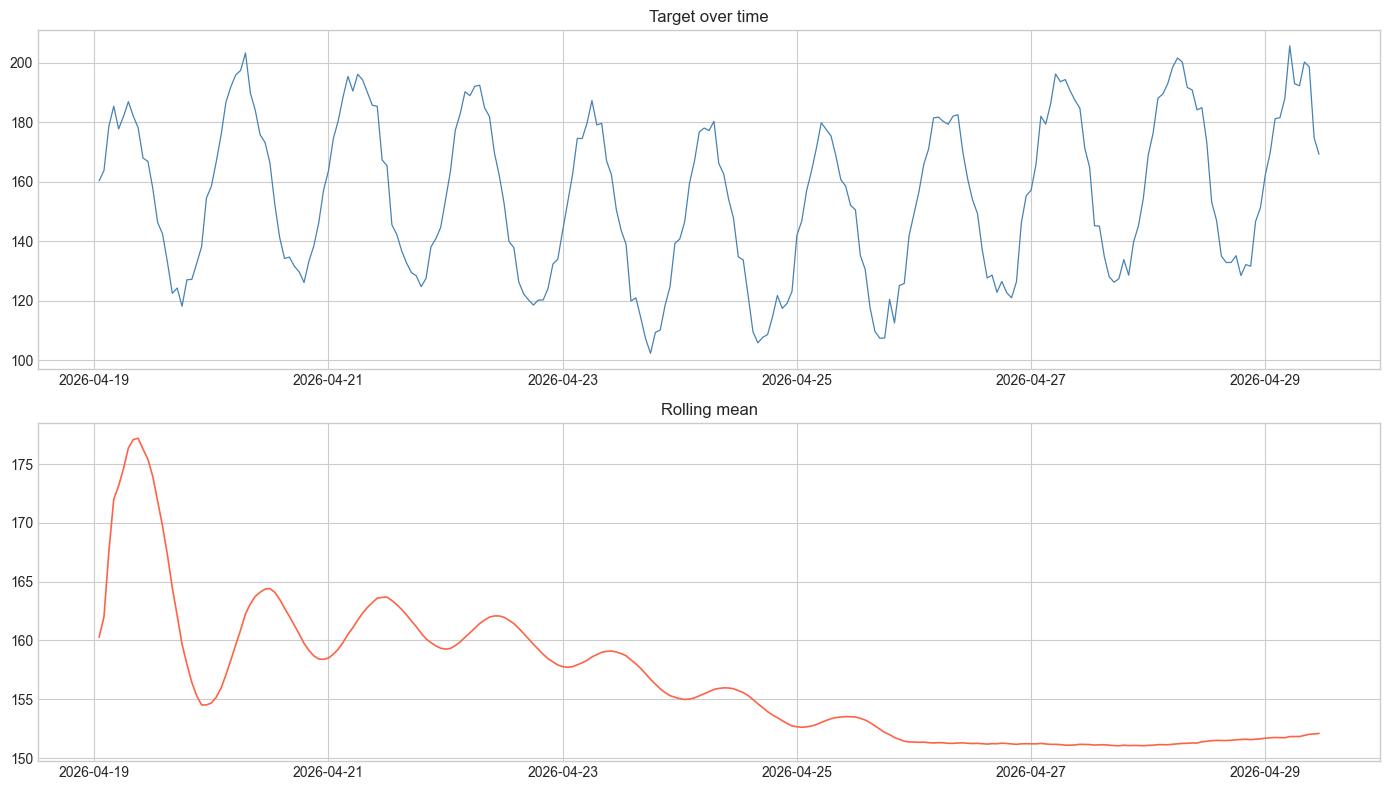

In [212]:
def describe_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    series = df['y'].dropna()
    summary = {
        'rows': len(df),
        'start': df['ds'].min(),
        'end': df['ds'].max(),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max(),
        'p05': series.quantile(0.05),
        'p95': series.quantile(0.95),
    }
    return pd.DataFrame([summary]).round(4)


profile_df = describe_dataset(raw_df)
display(profile_df)

if not raw_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(raw_df['ds'], raw_df['y'], color='steelblue', linewidth=0.9)
    axes[0].set_title('Target over time')

    rolling = raw_df['y'].rolling(window=min(24 * 7, max(3, len(raw_df))), min_periods=1).mean()
    axes[1].plot(raw_df['ds'], rolling, color='tomato', linewidth=1.2)
    axes[1].set_title('Rolling mean')

    plt.tight_layout()
    plt.show()

## 5. Train / validation / test split

Во manual workflow split должен быть воспроизводимым и явным. Рекомендуется time-based split без shuffle.

In [213]:
def build_splits(df: pd.DataFrame, config: TrainingNotebookConfig) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if df.empty:
        return df.copy(), df.copy(), df.copy()

    n_rows = len(df)
    train_end = int(n_rows * config.train_ratio)
    val_end = int(n_rows * (config.train_ratio + config.validation_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = build_splits(raw_df, cfg)
pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'start': [train_df['ds'].min() if not train_df.empty else None, val_df['ds'].min() if not val_df.empty else None, test_df['ds'].min() if not test_df.empty else None],
    'end': [train_df['ds'].max() if not train_df.empty else None, val_df['ds'].max() if not val_df.empty else None, test_df['ds'].max() if not test_df.empty else None],
})

,split,rows,start,end
0,train,175,2026-04-19 01:00:00+00:00,2026-04-26 07:00:00+00:00
1,validation,38,2026-04-26 08:00:00+00:00,2026-04-27 21:00:00+00:00
2,test,38,2026-04-27 22:00:00+00:00,2026-04-29 11:00:00+00:00


## 6. Baseline before complex models

Перед Prophet/XGBoost полезно иметь простой baseline. Это снижает риск переоценить сложный алгоритм без реальной прибавки качества.

In [214]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true != 0
    if not np.any(mask):
        return float('nan')
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = float(np.sum(np.abs(y_true)))
    if denominator == 0:
        return float('nan')
    numerator = float(np.sum(np.abs(y_true - y_pred)))
    return numerator / denominator


def evaluate_candidate(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, params: dict[str, Any] | None = None, fit_time_sec: float | None = None, notes: str = '') -> dict[str, Any]:
    return {
        'model_name': model_name,
        'status': 'ok',
        'fit_time_sec': None if fit_time_sec is None else round(fit_time_sec, 3),
        'metrics': {
            'mae': round(mae(y_true, y_pred), 4),
            'wape': round(wape(y_true, y_pred), 6),
            'mape': round(mape(y_true, y_pred), 6),
            'rmse': round(rmse(y_true, y_pred), 4),
        },
        'train_params': params or {},
        'notes': notes,
    }


def run_naive_last(train_df: pd.DataFrame, val_df: pd.DataFrame) -> dict[str, Any]:
    if train_df.empty or val_df.empty:
        return {'model_name': 'naive_last', 'status': 'skip', 'metrics': {}, 'train_params': {}, 'notes': 'Insufficient data'}

    last_value = float(train_df['y'].dropna().iloc[-1])
    predictions = np.full(shape=len(val_df), fill_value=last_value, dtype=float)
    actual = val_df['y'].to_numpy(dtype=float)
    return evaluate_candidate(actual, predictions, 'naive_last', notes='Repeats last observed value')


baseline_result = run_naive_last(train_df, val_df)
baseline_result

{'model_name': 'naive_last',
 'status': 'ok',
 'fit_time_sec': None,
 'metrics': {'mae': 29.2284,
  'wape': 0.189016,
  'mape': 0.213457,
  'rmse': 35.0164},
 'train_params': {},
 'notes': 'Repeats last observed value'}

## 7. Candidate algorithms and selection matrix

Эта матрица нужна, чтобы decision не сводился к одной метрике. Она должна оставаться расширяемой для новых алгоритмов.

In [215]:
candidate_matrix = pd.DataFrame([
    {
        'algorithm': 'naive_last',
        'seasonality_strength': 'low',
        'external_regressors': 'no',
        'interpretability': 'high',
        'training_cost': 'low',
        'inference_cost': 'low',
        'recommended_when': 'Need quick baseline',
    },
    {
        'algorithm': 'prophet',
        'seasonality_strength': 'high',
        'external_regressors': 'limited',
        'interpretability': 'high',
        'training_cost': 'medium',
        'inference_cost': 'low',
        'recommended_when': 'Strong trend/seasonality and explainability matter',
    },
    {
        'algorithm': 'xgboost',
        'seasonality_strength': 'medium',
        'external_regressors': 'yes',
        'interpretability': 'medium',
        'training_cost': 'medium',
        'inference_cost': 'medium',
        'recommended_when': 'Rich features and nonlinear dependencies',
    },
    {
        'algorithm': 'new_algorithm_template',
        'seasonality_strength': 'tbd',
        'external_regressors': 'tbd',
        'interpretability': 'tbd',
        'training_cost': 'tbd',
        'inference_cost': 'tbd',
        'recommended_when': 'Fill when adding a new adapter',
    },
])
candidate_matrix

,algorithm,seasonality_strength,external_regressors,interpretability,training_cost,inference_cost,recommended_when
0,naive_last,low,no,high,low,low,Need quick baseline
1,prophet,high,limited,high,medium,low,Strong trend/seasonality and explainability ma...
2,xgboost,medium,yes,medium,medium,medium,Rich features and nonlinear dependencies
3,new_algorithm_template,tbd,tbd,tbd,tbd,tbd,Fill when adding a new adapter


## 8. Candidate training: Prophet

Используйте эту ячейку, если ряд стабилен по timestamp и важна интерпретируемость тренда/сезонности. Импорт Prophet выполняется лениво, чтобы notebook оставался открываемым даже без пакета.

In [216]:
def train_prophet_candidate(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    try:
        from prophet import Prophet
    except ImportError as exc:
        return {
            'model_name': 'prophet',
            'status': 'skip',
            'metrics': {},
            'train_params': params,
            'notes': f'Prophet is not installed: {exc}',
            'model_object': None,
        }

    if train_df.empty or val_df.empty:
        return {'model_name': 'prophet', 'status': 'skip', 'metrics': {}, 'train_params': params, 'notes': 'Insufficient data', 'model_object': None}

    fit_df = train_df[['ds', 'y']].dropna().copy()
    # Prophet requires timezone-naive datetimes in ds.
    fit_df['ds'] = pd.to_datetime(fit_df['ds'], errors='coerce')
    if getattr(fit_df['ds'].dt, 'tz', None) is not None:
        fit_df['ds'] = fit_df['ds'].dt.tz_localize(None)

    model = Prophet(**params)
    started = time.perf_counter()
    model.fit(fit_df)
    fit_time_sec = time.perf_counter() - started

    future = val_df[['ds']].copy()
    future['ds'] = pd.to_datetime(future['ds'], errors='coerce')
    if getattr(future['ds'].dt, 'tz', None) is not None:
        future['ds'] = future['ds'].dt.tz_localize(None)

    forecast = model.predict(future)
    y_true = val_df['y'].to_numpy(dtype=float)
    y_pred = forecast['yhat'].to_numpy(dtype=float)

    result = evaluate_candidate(y_true, y_pred, 'prophet', params=params, fit_time_sec=fit_time_sec, notes='Prophet validation forecast')
    result['model_object'] = model
    return result


prophet_result = train_prophet_candidate(train_df, val_df, cfg.prophet_params or {}) if 'prophet' in cfg.active_candidates else None
prophet_result


06:39:59 - cmdstanpy - INFO - Chain [1] start processing
06:39:59 - cmdstanpy - INFO - Chain [1] done processing


{'model_name': 'prophet',
 'status': 'ok',
 'fit_time_sec': 0.064,
 'metrics': {'mae': 3.4939, 'wape': 0.022594, 'mape': 0.02278, 'rmse': 4.3363},
 'train_params': {'seasonality_mode': 'multiplicative',
  'changepoint_prior_scale': 0.05,
  'weekly_seasonality': True,
  'daily_seasonality': True},
 'notes': 'Prophet validation forecast',
 'model_object': <prophet.forecaster.Prophet at 0x149c0df90>}

## 9. Candidate training: XGBoost

Этот блок отражает общую идею из `scripts/train_xgb.py`: лаги, календарные признаки и оценка на holdout. Для production-specific data fetch и artifact registration используйте соответствующий script/MLflow workflow.

In [217]:
def build_xgb_frame(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    frame = df[['ds', target_col]].copy()
    frame['hour'] = frame['ds'].dt.hour
    frame['dayofweek'] = frame['ds'].dt.dayofweek
    for lag in (1, 2, 3, 24, 48, 168):
        frame[f'lag_{lag}'] = frame[target_col].shift(lag)
    return frame.dropna().reset_index(drop=True)


def train_xgb_candidate(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    if xgb is None:
        return {
            'model_name': 'xgboost',
            'status': 'skip',
            'metrics': {},
            'train_params': params,
            'notes': 'xgboost is not installed',
        }

    if train_df.empty or val_df.empty:
        return {'model_name': 'xgboost', 'status': 'skip', 'metrics': {}, 'train_params': params, 'notes': 'Insufficient data'}

    merged = pd.concat([train_df, val_df], ignore_index=True)
    feature_frame = build_xgb_frame(merged)
    split_ts = val_df['ds'].min()

    train_features = feature_frame[feature_frame['ds'] < split_ts].copy()
    val_features = feature_frame[feature_frame['ds'] >= split_ts].copy()

    predictors = [col for col in train_features.columns if col not in {'ds', 'y'}]
    model = xgb.XGBRegressor(**params)
    started = time.perf_counter()
    model.fit(train_features[predictors], train_features['y'])
    fit_time_sec = time.perf_counter() - started

    y_true = val_features['y'].to_numpy(dtype=float)
    y_pred = model.predict(val_features[predictors]).astype(float)
    notes = f'Predictors: {len(predictors)}'
    return evaluate_candidate(y_true, y_pred, 'xgboost', params=params, fit_time_sec=fit_time_sec, notes=notes)


xgb_result = train_xgb_candidate(train_df, val_df, cfg.xgb_params or {}) if 'xgboost' in cfg.active_candidates else None
xgb_result

{'model_name': 'xgboost',
 'status': 'ok',
 'fit_time_sec': 0.386,
 'metrics': {'mae': 25.6686,
  'wape': 0.165995,
  'mape': 0.187051,
  'rmse': 30.7711},
 'train_params': {'objective': 'reg:squarederror',
  'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'random_state': 42},
 'notes': 'Predictors: 8'}

## 10. Визуализация прогноза на тесте

Сравниваем прогнозы `naive_last`, `prophet`, `xgboost` на тестовом периоде.
Для XGBoost модель дообучается на `train+validation`, затем строится прогноз на `test`.
Вывод:
- график факт vs прогноз;
- таблица метрик на тесте: MAE, RMSE, MAPE, количество точек.

,model,points,mae,wape,rmse,mape
0,xgboost,38,4.9936,0.029267,6.2475,0.028490
1,prophet,38,7.7973,0.045699,9.3042,0.044877
2,naive_last,38,21.0688,0.123481,25.7788,0.137388


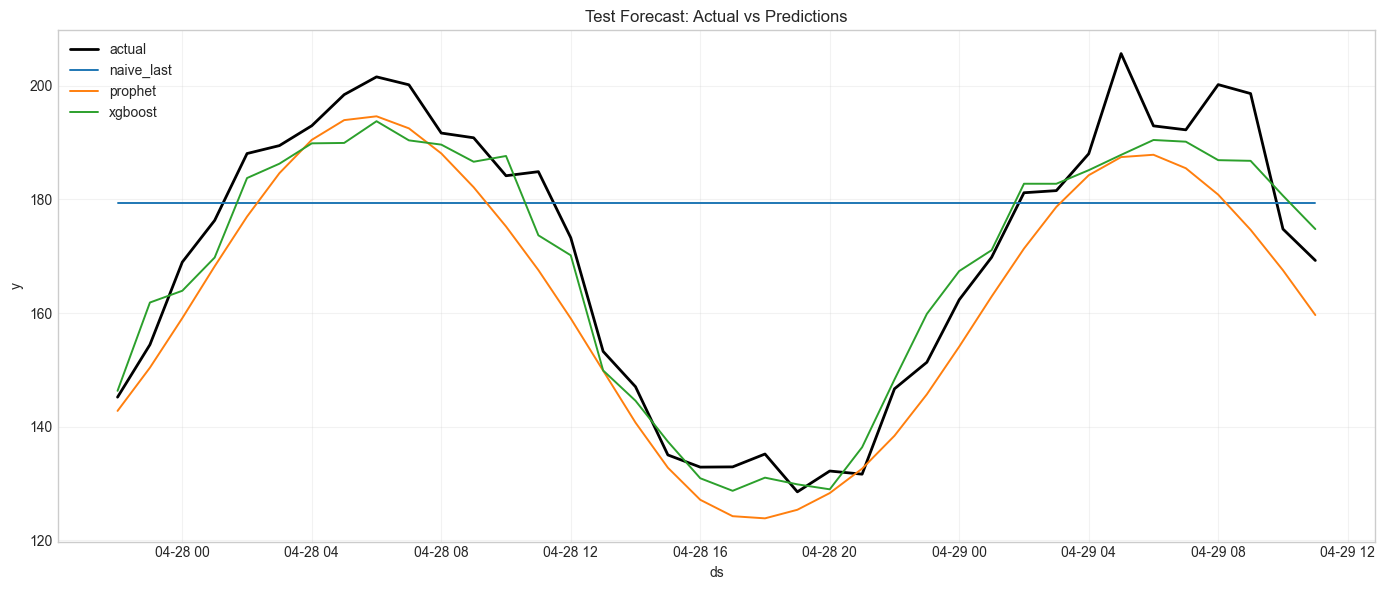

In [218]:
test_base = test_df[['ds', 'y']].copy().rename(columns={'y': 'actual'})
test_base['ds'] = pd.to_datetime(test_base['ds'], errors='coerce')

pred_tables: list[pd.DataFrame] = []

# naive_last on test
if not train_df.empty and not test_base.empty:
    last_value = float(train_df['y'].dropna().iloc[-1])
    naive_tbl = test_base[['ds']].copy()
    naive_tbl['naive_last'] = last_value
    pred_tables.append(naive_tbl)

# prophet on test
if prophet_result and prophet_result.get('status') == 'ok' and prophet_result.get('model_object') is not None:
    prophet_model = prophet_result['model_object']
    future = test_base[['ds']].copy()
    if getattr(future['ds'].dt, 'tz', None) is not None:
        future['ds'] = future['ds'].dt.tz_localize(None)
    prophet_fcst = prophet_model.predict(future)
    prophet_tbl = test_base[['ds']].copy()
    prophet_tbl['prophet'] = prophet_fcst['yhat'].to_numpy(dtype=float)
    pred_tables.append(prophet_tbl)

# xgboost on test (retrain on train+validation)
if xgb is not None and not train_df.empty and not val_df.empty and not test_df.empty:
    tv_df = pd.concat([train_df, val_df], ignore_index=True).sort_values('ds').reset_index(drop=True)
    all_df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values('ds').reset_index(drop=True)

    tv_feat = build_xgb_frame(tv_df)
    all_feat = build_xgb_frame(all_df)
    test_start = pd.to_datetime(test_df['ds'].min(), errors='coerce')
    test_feat = all_feat[all_feat['ds'] >= test_start].copy()

    if not tv_feat.empty and not test_feat.empty:
        predictors = [c for c in tv_feat.columns if c not in {'ds', 'y'}]
        xgb_model = xgb.XGBRegressor(**(cfg.xgb_params or {}))
        xgb_model.fit(tv_feat[predictors], tv_feat['y'])
        xgb_pred = xgb_model.predict(test_feat[predictors]).astype(float)

        xgb_tbl = test_feat[['ds']].copy()
        xgb_tbl['xgboost'] = xgb_pred
        pred_tables.append(xgb_tbl)

# align by ds
viz_df = test_base.copy()
for tbl in pred_tables:
    viz_df = viz_df.merge(tbl, on='ds', how='left')

# metrics table
metric_rows: list[dict[str, Any]] = []
for model_col in ['naive_last', 'prophet', 'xgboost']:
    if model_col not in viz_df.columns:
        continue
    mask = viz_df['actual'].notna() & viz_df[model_col].notna()
    if int(mask.sum()) == 0:
        continue
    y_true = viz_df.loc[mask, 'actual'].to_numpy(dtype=float)
    y_pred = viz_df.loc[mask, model_col].to_numpy(dtype=float)
    metric_rows.append({
        'model': model_col,
        'points': int(mask.sum()),
        'mae': round(mae(y_true, y_pred), 4),
        'wape': round(wape(y_true, y_pred), 6),
        'rmse': round(rmse(y_true, y_pred), 4),
        'mape': round(mape(y_true, y_pred), 6),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values('mae', na_position='last').reset_index(drop=True)
display(metrics_df)

# chart
plt.figure(figsize=(14, 6))
plt.plot(viz_df['ds'], viz_df['actual'], label='actual', color='black', linewidth=2)
for model_col in ['naive_last', 'prophet', 'xgboost']:
    if model_col in viz_df.columns:
        plt.plot(viz_df['ds'], viz_df[model_col], label=model_col, linewidth=1.4)
plt.title('Test Forecast: Actual vs Predictions')
plt.xlabel('ds')
plt.ylabel('y')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Шаблон для нового алгоритма

Чтобы добавить новую модель, сохраните тот же результат-формат: `model_name`, `status`, `fit_time_sec`, `metrics`, `train_params`, `notes`. Это позволяет не переписывать comparison и reporting sections.

In [219]:
def train_new_algorithm_template(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    notes = (
        'Replace with adapter-specific training logic that returns the common result schema. '
        f'Current split sizes: train={len(train_df)}, validation={len(val_df)}'
    )
    return {
        'model_name': 'new_algorithm_template',
        'status': 'skip',
        'fit_time_sec': None,
        'metrics': {},
        'train_params': params,
        'notes': notes,
    }


template_result = train_new_algorithm_template(train_df, val_df, {})
template_result

{'model_name': 'new_algorithm_template',
 'status': 'skip',
 'fit_time_sec': None,
 'metrics': {},
 'train_params': {},
 'notes': 'Replace with adapter-specific training logic that returns the common result schema. Current split sizes: train=175, validation=38'}

## 11. Сравнение моделей и выбор алгоритма

Здесь все кандидаты приводятся к общей comparison table. Именно этот блок нужен для decision memo и ручного выбора алгоритма.

In [220]:
def build_model_comparison(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for result in results:
        if not result or result.get('status') == 'skip':
            rows.append({
                'model_name': result.get('model_name') if result else 'unknown',
                'status': result.get('status') if result else 'missing',
                'fit_time_sec': result.get('fit_time_sec') if result else None,
                'mae': np.nan,
                'wape': np.nan,
                'mape': np.nan,
                'rmse': np.nan,
                'notes': result.get('notes', '') if result else '',
            })
            continue

        rows.append({
            'model_name': result['model_name'],
            'status': result['status'],
            'fit_time_sec': result.get('fit_time_sec'),
            'mae': result['metrics'].get('mae'),
            'wape': result['metrics'].get('wape'),
            'mape': result['metrics'].get('mape'),
            'rmse': result['metrics'].get('rmse'),
            'notes': result.get('notes', ''),
        })

    comparison = pd.DataFrame(rows)
    if 'mae' in comparison.columns:
        comparison = comparison.sort_values(by=['status', 'mae'], ascending=[True, True], na_position='last').reset_index(drop=True)
    return comparison


results = [baseline_result, prophet_result, xgb_result, template_result]
comparison_df = build_model_comparison([item for item in results if item is not None])
comparison_df

,model_name,status,fit_time_sec,mae,wape,mape,rmse,notes
0,prophet,ok,0.064,3.4939,0.022594,0.022780,4.3363,Prophet validation forecast
1,xgboost,ok,0.386,25.6686,0.165995,0.187051,30.7711,Predictors: 8
2,naive_last,ok,NaN,29.2284,0.189016,0.213457,35.0164,Repeats last observed value
3,new_algorithm_template,skip,NaN,NaN,NaN,NaN,NaN,Replace with adapter-specific training logic t...


## 12. Подготовка отчета

Отчет должен быть полезен и человеку, и последующему pipeline review. Минимум: summary по данным, comparison table, recommendation, список рисков и следующего шага.

In [221]:
def make_recommendation(comparison_df: pd.DataFrame, quality_df: pd.DataFrame, wape_warn_threshold: float = 1.0) -> dict[str, Any]:
    ready_rows = comparison_df[(comparison_df['status'] == 'ok') & comparison_df['mae'].notna()]
    best_model = ready_rows.sort_values('mae').iloc[0]['model_name'] if not ready_rows.empty else None

    warnings = quality_df[quality_df['status'] != 'ok']['check'].tolist() if not quality_df.empty else []
    reasons = []

    if best_model is not None:
        reasons.append(f'Lowest validation MAE among ready candidates: {best_model}')

        best_row = ready_rows[ready_rows['model_name'] == best_model].iloc[0]
        best_mae = float(best_row['mae']) if pd.notna(best_row.get('mae')) else float('nan')
        best_wape = float(best_row['wape']) if pd.notna(best_row.get('wape')) else float('nan')

        if not math.isnan(best_mae):
            reasons.append(f'Validation MAE for selected model: {best_mae:.4f}')
        if not math.isnan(best_wape):
            reasons.append(f'Validation WAPE for selected model: {best_wape:.6f}')
            if best_wape > wape_warn_threshold:
                warnings.append(f'wape_above_threshold({wape_warn_threshold})')

    if warnings:
        reasons.append('Data quality/performance warnings must be reviewed before publication')

    return {
        'recommended_model': best_model,
        'reasons': reasons,
        'data_warnings': warnings,
        'next_actions': [
            'Review data quality warnings',
            'Validate recommendation on recent holdout',
            'Publish artifact bundle and config if model is approved',
        ],
    }


recommendation = make_recommendation(comparison_df, quality_df)
recommendation

{'recommended_model': 'prophet',
 'reasons': ['Lowest validation MAE among ready candidates: prophet',
  'Validation MAE for selected model: 3.4939',
  'Validation WAPE for selected model: 0.022594',
  'Data quality/performance warnings must be reviewed before publication'],
 'data_warnings': ['min_sample_size'],
 'next_actions': ['Review data quality warnings',
  'Validate recommendation on recent holdout',
  'Publish artifact bundle and config if model is approved']}

## 13. Экспорт report bundle

Этот экспорт не заменяет MLflow logging, а создает human-readable companion artifacts для review и согласования.

In [228]:
def export_report_bundle(report_dir: Path, quality_df: pd.DataFrame, profile_df: pd.DataFrame, comparison_df: pd.DataFrame, recommendation: dict[str, Any]) -> dict[str, str]:
    report_dir.mkdir(parents=True, exist_ok=True)
    outputs = {
        'data_quality_summary': str(report_dir / 'data_quality_summary.csv'),
        'dataset_profile': str(report_dir / 'dataset_profile.csv'),
        'model_comparison': str(report_dir / 'model_comparison.csv'),
        'recommendation': str(report_dir / 'recommendation.json'),
    }

    quality_df.to_csv(outputs['data_quality_summary'], index=False)
    profile_df.to_csv(outputs['dataset_profile'], index=False)
    comparison_df.to_csv(outputs['model_comparison'], index=False)
    Path(outputs['recommendation']).write_text(json.dumps(recommendation, ensure_ascii=False, indent=2))
    return outputs


report_outputs = export_report_bundle(cfg.training_reports_dir, quality_df, profile_df, comparison_df, recommendation)
report_outputs

{'data_quality_summary': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/reports/data_quality_summary.csv',
 'dataset_profile': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/reports/dataset_profile.csv',
 'model_comparison': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/reports/model_comparison.csv',
 'recommendation': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/reports/recommendation.json'}

## 14. Optional strict workflow: MLflow-compatible bundle and logging

Этот блок делает manual training "публикационно-готовым":

- формирует совместимый layout `bundle/model` + `bundle/configuration/cache_config.json`;
- сохраняет metadata и exported reports в `bundle/assets`;
- опционально логирует все это в MLflow run.

Включение режима: `cfg.mlflow_enabled = True`.

In [229]:
def compute_dataset_hash(df: pd.DataFrame) -> str:
    buf = io.BytesIO()
    df.to_parquet(buf, index=False)
    return hashlib.sha256(buf.getvalue()).hexdigest()


def build_dataset_snapshot_files(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    assets_dir: Path,
) -> dict[str, str]:
    datasets_dir = assets_dir / 'datasets'
    datasets_dir.mkdir(parents=True, exist_ok=True)

    snapshots: dict[str, str] = {}
    for split_name, split_df in (('train', train_df), ('validation', val_df), ('test', test_df)):
        output_path = datasets_dir / f'{split_name}_snapshot.parquet'
        split_df.to_parquet(output_path, index=False)
        snapshots[f'{split_name}_snapshot'] = str(output_path)

    return snapshots


def build_runtime_cache_config(config: TrainingNotebookConfig, best_result: dict[str, Any] | None) -> dict[str, Any]:
    model_type = best_result.get('model_name') if best_result else 'unknown'
    return {
        'step': 3600,
        'input_range': None,
        'output_range': int(config.forecast_horizon),
        'clip_negatives_to_0': True,
        'use_dynamic_normalization': False,
        'model_type': str(model_type),
        'fallback': 'none',
        'archives': [],
        'historical_data_url': None,
        'historical_data_request_overrides': {},
        'weather_lat': None,
        'weather_lon': None,
        'weather_url': None,
        'weather_units': 'metric',
        'weather_hours': int(config.forecast_horizon),
        'cmms_url': None,
        'cmms_request_overrides': {},
    }


def _serialize_model_payload(model_name: str, model_object: Any, model_dir: Path) -> dict[str, Any]:
    model_dir.mkdir(parents=True, exist_ok=True)
    metadata: dict[str, Any] = {'model_name': model_name, 'saved': False, 'format': None, 'path': None, 'notes': ''}

    if model_object is None:
        metadata['notes'] = 'Model object is missing, serialization skipped'
        return metadata

    if model_name == 'xgboost' and hasattr(model_object, 'save_model'):
        output_path = model_dir / 'model.xgb.json'
        model_object.save_model(str(output_path))
        metadata.update({'saved': True, 'format': 'xgboost_json', 'path': str(output_path)})
        return metadata

    if model_name == 'prophet':
        try:
            from prophet.serialize import model_to_json
            output_path = model_dir / 'model.prophet.json'
            output_path.write_text(model_to_json(model_object))
            metadata.update({'saved': True, 'format': 'prophet_json', 'path': str(output_path)})
            return metadata
        except Exception as exc:
            metadata['notes'] = f'Prophet JSON serialization failed: {exc}'
            return metadata

    metadata['notes'] = f'Unsupported model_name for serializer: {model_name}'
    return metadata


def build_mlflow_compatible_bundle(
    config: TrainingNotebookConfig,
    comparison_df: pd.DataFrame,
    quality_df: pd.DataFrame,
    recommendation: dict[str, Any],
    report_outputs: dict[str, str],
    candidate_results: list[dict[str, Any]],
    raw_df: pd.DataFrame,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict[str, Any]:
    bundle_root = Path(config.bundle_output_dir)
    model_dir = bundle_root / 'bundle' / 'model'
    conf_dir = bundle_root / 'bundle' / 'configuration'
    assets_dir = bundle_root / 'bundle' / 'assets'

    if bundle_root.exists():
        shutil.rmtree(bundle_root)
    assets_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    conf_dir.mkdir(parents=True, exist_ok=True)

    selected_model_name = recommendation.get('recommended_model')
    selected_result = None
    for item in candidate_results:
        if item.get('model_name') == selected_model_name and item.get('status') == 'ok':
            selected_result = item
            break

    serializer_info = _serialize_model_payload(
        model_name=selected_model_name or 'unknown',
        model_object=None if selected_result is None else selected_result.get('model_object'),
        model_dir=model_dir,
    )

    cache_config = build_runtime_cache_config(config, selected_result)
    cache_config_path = conf_dir / 'cache_config.json'
    cache_config_path.write_text(json.dumps(cache_config, ensure_ascii=False, indent=2))

    snapshot_paths: dict[str, str] = {}
    if config.dataset_snapshot_enabled:
        snapshot_paths = build_dataset_snapshot_files(train_df, val_df, test_df, assets_dir)

    dataset_lineage = {
        'dataset_uri': str(config.dataset_path),
        'dataset_hash': compute_dataset_hash(raw_df),
        'row_count': int(len(raw_df)),
        'start_ts': str(raw_df['ds'].min()) if not raw_df.empty else None,
        'end_ts': str(raw_df['ds'].max()) if not raw_df.empty else None,
        'feature_schema_version': str(config.feature_schema_version),
        'snapshot_paths': snapshot_paths,
    }

    manifest = {
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'object_reference': config.object_reference,
        'model_id': config.mlflow_model_registry_name,
        'recommended_model': selected_model_name,
        'serializer': serializer_info,
        'metrics_table_rows': int(len(comparison_df)),
        'quality_checks_rows': int(len(quality_df)),
        'dataset_lineage': dataset_lineage,
        'storage': {
            'model_store_root': str(config.model_store_root),
            'model_home_dir': str(config.model_home_dir),
            'training_artifacts_dir': str(config.training_artifacts_dir),
            'runtime_cache_dir': str(config.runtime_cache_dir),
        },
    }
    manifest_path = assets_dir / 'manual_training_manifest.json'
    manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

    copied_reports: dict[str, str] = {}
    for key, report_path in report_outputs.items():
        src = Path(report_path)
        if src.exists():
            dst = assets_dir / src.name
            shutil.copy2(src, dst)
            copied_reports[key] = str(dst)

    return {
        'bundle_root': str(bundle_root),
        'model_id': str(config.mlflow_model_registry_name),
        'model_dir': str(model_dir),
        'cache_config_path': str(cache_config_path),
        'manifest_path': str(manifest_path),
        'copied_reports': copied_reports,
        'serializer': serializer_info,
        'dataset_lineage': dataset_lineage,
    }


def optional_log_bundle_to_mlflow(
    config: TrainingNotebookConfig,
    recommendation: dict[str, Any],
    best_result: dict[str, Any] | None,
    bundle_info: dict[str, Any],
) -> dict[str, Any]:
    if not config.mlflow_enabled:
        return {'status': 'skipped', 'reason': 'cfg.mlflow_enabled=False'}

    try:
        import mlflow
    except ImportError as exc:
        return {'status': 'skipped', 'reason': f'mlflow is not installed: {exc}'}

    if config.mlflow_tracking_uri:
        mlflow.set_tracking_uri(config.mlflow_tracking_uri)
    mlflow.set_experiment(config.mlflow_experiment_name)

    run_name = f"{config.mlflow_run_name_prefix}_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}"

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag('object_reference', config.object_reference)
        mlflow.set_tag('model_id', config.mlflow_model_registry_name)
        mlflow.set_tag('flow_type', 'manual_notebook')
        mlflow.set_tag('recommended_model', str(recommendation.get('recommended_model')))
        mlflow.set_tag('bundle_layout', 'bundle/model + bundle/configuration/cache_config.json')

        if best_result is not None:
            for key, value in (best_result.get('train_params') or {}).items():
                mlflow.log_param(f'train_params.{key}', value)
            for metric_name, metric_value in (best_result.get('metrics') or {}).items():
                if metric_value is not None and not (isinstance(metric_value, float) and math.isnan(metric_value)):
                    mlflow.log_metric(metric_name, float(metric_value))

        lineage = bundle_info.get('dataset_lineage') or {}
        if lineage:
            mlflow.set_tag('dataset_uri', str(lineage.get('dataset_uri')))
            mlflow.set_tag('dataset_hash', str(lineage.get('dataset_hash')))
            mlflow.log_param('row_count', int(lineage.get('row_count', 0)))
            mlflow.set_tag('start_ts', str(lineage.get('start_ts')))
            mlflow.set_tag('end_ts', str(lineage.get('end_ts')))
            mlflow.set_tag('feature_schema_version', str(lineage.get('feature_schema_version')))

        mlflow.log_artifacts(bundle_info['bundle_root'], artifact_path='bundle')
        mlflow.log_artifacts(str(cfg.training_reports_dir), artifact_path='reports')

        return {
            'status': 'ok',
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
            'tracking_uri': mlflow.get_tracking_uri(),
        }

In [230]:
def optional_log_bundle_to_mlflow(
    config: TrainingNotebookConfig,
    recommendation: dict[str, Any],
    best_result: dict[str, Any] | None,
    bundle_info: dict[str, Any],
) -> dict[str, Any]:
    bundle_root = Path(str(bundle_info.get('bundle_root', '')))
    bundle_saved = bool(bundle_info) and str(bundle_root) != '.' and bundle_root.exists()

    if not config.mlflow_enabled:
        return {
            'status': 'skipped',
            'reason': 'cfg.mlflow_enabled=False',
            'bundle_saved': bundle_saved,
            'local_bundle_root': str(bundle_root),
        }

    try:
        import mlflow
        from mlflow.tracking import MlflowClient
    except ImportError as exc:
        return {
            'status': 'skipped',
            'reason': f'mlflow is not installed: {exc}',
            'bundle_saved': bundle_saved,
            'local_bundle_root': str(bundle_root),
        }

    if config.mlflow_tracking_uri:
        mlflow.set_tracking_uri(config.mlflow_tracking_uri)
    mlflow.set_experiment(config.mlflow_experiment_name)

    run_name = f"{config.mlflow_run_name_prefix}_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}"
    artifact_errors: list[str] = []

    def _safe_log_artifacts(local_dir: str | Path | None, artifact_path: str) -> None:
        if local_dir is None:
            artifact_errors.append(f'{artifact_path}: local_dir is None')
            return
        src = Path(local_dir)
        if not src.exists():
            artifact_errors.append(f'{artifact_path}: local_dir does not exist -> {src}')
            return
        try:
            mlflow.log_artifacts(str(src), artifact_path=artifact_path)
        except Exception as exc:
            artifact_errors.append(f'{artifact_path}: {type(exc).__name__}: {exc}')

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag('object_reference', config.object_reference)
        mlflow.set_tag('model_id', config.mlflow_model_registry_name)
        mlflow.set_tag('flow_type', 'manual_notebook')
        mlflow.set_tag('recommended_model', str(recommendation.get('recommended_model')))
        mlflow.set_tag('bundle_layout', 'bundle/model + bundle/configuration/cache_config.json')
        mlflow.set_tag('bundle_saved_locally', str(bundle_saved))

        if best_result is not None:
            for key, value in (best_result.get('train_params') or {}).items():
                mlflow.log_param(f'train_params.{key}', value)
            for metric_name, metric_value in (best_result.get('metrics') or {}).items():
                if metric_value is not None and not (isinstance(metric_value, float) and math.isnan(metric_value)):
                    mlflow.log_metric(metric_name, float(metric_value))

        lineage = bundle_info.get('dataset_lineage') or {}
        if lineage:
            mlflow.set_tag('dataset_uri', str(lineage.get('dataset_uri')))
            mlflow.set_tag('dataset_hash', str(lineage.get('dataset_hash')))
            mlflow.log_param('row_count', int(lineage.get('row_count', 0)))
            mlflow.set_tag('start_ts', str(lineage.get('start_ts')))
            mlflow.set_tag('end_ts', str(lineage.get('end_ts')))
            mlflow.set_tag('feature_schema_version', str(lineage.get('feature_schema_version')))

        _safe_log_artifacts(bundle_info.get('bundle_root'), artifact_path='bundle')
        _safe_log_artifacts(config.training_reports_dir, artifact_path='reports')

        result = {
            'status': 'ok' if not artifact_errors else 'partial',
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
            'tracking_uri': mlflow.get_tracking_uri(),
            'bundle_saved': bundle_saved,
            'local_bundle_root': str(bundle_root),
        }
        if artifact_errors:
            result['artifact_warnings'] = artifact_errors

    # ── Регистрация в MLflow Registry + alias Production ─────────────────────
    registry_name = config.mlflow_model_registry_name
    alias_name = 'Production'
    run_id = result['run_id']
    has_bundle_artifact_error = any(msg.startswith('bundle:') for msg in artifact_errors)
    if has_bundle_artifact_error:
        result.setdefault('artifact_warnings', [])
        result['artifact_warnings'].append('registry: skipped because bundle artifact was not logged')
        return result
    try:
        client = MlflowClient(tracking_uri=config.mlflow_tracking_uri)
        version = client.create_model_version(
            name=registry_name,
            source=f'runs:/{run_id}/bundle',
            run_id=run_id,
        )
        client.set_registered_model_alias(
            name=registry_name,
            alias=alias_name,
            version=version.version,
        )
        result['registry_name'] = registry_name
        result['model_version'] = version.version
        result['model_alias'] = alias_name
    except Exception as exc:
        result.setdefault('artifact_warnings', [])
        result['artifact_warnings'].append(f'registry: {type(exc).__name__}: {exc}')

    return result

In [231]:
candidate_results = [item for item in [baseline_result, prophet_result, xgb_result, template_result] if item is not None]
best_model_name = recommendation.get('recommended_model')
best_result = next((item for item in candidate_results if item.get('model_name') == best_model_name and item.get('status') == 'ok'), None)

bundle_info = build_mlflow_compatible_bundle(
    config=cfg,
    comparison_df=comparison_df,
    quality_df=quality_df,
    recommendation=recommendation,
    report_outputs=report_outputs,
    candidate_results=candidate_results,
    raw_df=raw_df,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
)

mlflow_result = optional_log_bundle_to_mlflow(
    config=cfg,
    recommendation=recommendation,
    best_result=best_result,
    bundle_info=bundle_info,
)

{
    'bundle_info': bundle_info,
    'mlflow_result': mlflow_result,
}

2026/05/04 07:48:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt, version 12


🏃 View run manual_training_20260504_024824 at: http://127.0.0.1:5050/#/experiments/3/runs/837d4ecf7ed14f949e2cbf7f0a3ba9df
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/3


{'bundle_info': {'bundle_root': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/bundle_export',
  'model_id': 'root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt',
  'model_dir': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/bundle_export/bundle/model',
  'cache_config_path': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/bundle_export/bundle/configuration/cache_config.json',
  'manifest_path': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/bundle_export/bundle/assets/manual_training_manifest.json',
  'copied_reports': {'data_quality_summary': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt/training/bundle_export/bundle/asse

In [232]:
# ── Проверка: модель зарегистрирована и доступна через alias Production ────
from mlflow.tracking import MlflowClient as _MlflowClient

_client = _MlflowClient(tracking_uri=cfg.mlflow_tracking_uri)
_reg_name = cfg.mlflow_model_registry_name

try:
    _mv = _client.get_model_version_by_alias(_reg_name, 'Production')
    print('OK  Registry:')
    print(f'   model_id (registry_name) : {_reg_name}')
    print(f'   version                  : {_mv.version}')
    print(f'   run_id                   : {_mv.run_id}')
    print(f'   artifact source          : {_mv.source}')
    print()
    print('Для запроса к prod серверу используйте:')
    print(f'  "model_id": "{_reg_name}",')
    print( '  "model_selection": {"version_alias": "Production"}')
except Exception as _exc:
    print(f'FAIL  Registry lookup failed: {_exc}')
    if 'mlflow_result' in dir() and mlflow_result.get('registry_name'):
        print(f'   registry_name in result  : {mlflow_result["registry_name"]}')
        print(f'   model_version in result  : {mlflow_result.get("model_version")}')


OK  Registry:
   model_id (registry_name) : root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt
   version                  : 12
   run_id                   : 837d4ecf7ed14f949e2cbf7f0a3ba9df
   artifact source          : runs:/837d4ecf7ed14f949e2cbf7f0a3ba9df/bundle

Для запроса к prod серверу используйте:
  "model_id": "root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt",
  "model_selection": {"version_alias": "Production"}


In [233]:
from mlflow.tracking import MlflowClient as _MlflowClient

def _find_local_run_dir(mlruns_root: Path, run_id: str) -> Path | None:
    for exp_dir in mlruns_root.iterdir():
        if not exp_dir.is_dir() or exp_dir.name == 'manual_reg':
            continue
        candidate = exp_dir / run_id
        if candidate.exists():
            return candidate
    return None


def _offline_training_status(model_home_dir: Path) -> tuple[str, dict[str, bool]]:
    training_root = model_home_dir / 'training'
    report_ok = (training_root / 'reports' / 'recommendation.json').exists()
    manifest_ok = (training_root / 'bundle_export' / 'bundle' / 'assets' / 'manual_training_manifest.json').exists()
    cache_cfg_ok = (training_root / 'bundle_export' / 'bundle' / 'configuration' / 'cache_config.json').exists()

    checks = {
        'report_ok': report_ok,
        'manifest_ok': manifest_ok,
        'cache_config_ok': cache_cfg_ok,
    }
    ok_count = sum(int(v) for v in checks.values())
    if ok_count == 3:
        return 'trained', checks
    if ok_count > 0:
        return 'partial', checks
    return 'missing', checks


def _production_alias_info(client: _MlflowClient | None, model_id: str) -> dict[str, Any]:
    if client is None:
        return {'alias_status': 'unknown', 'run_id': None, 'model_version': None, 'alias': None, 'reason': 'registry_unavailable'}
    try:
        mv = client.get_model_version_by_alias(model_id, 'Production')
        return {
            'alias_status': 'present',
            'run_id': str(mv.run_id),
            'model_version': str(mv.version),
            'alias': 'Production',
            'reason': '',
        }
    except Exception as exc:
        return {
            'alias_status': 'missing',
            'run_id': None,
            'model_version': None,
            'alias': None,
            'reason': str(exc),
        }


def build_reconciliation_audit_df(config: TrainingNotebookConfig) -> pd.DataFrame:
    # Candidate list from already loaded batch table; fallback to CSV read if needed.
    if '_models' in globals() and isinstance(_models, pd.DataFrame):
        ref = _models.copy()
    else:
        ref = _read_models_csv(BATCH_MODELS_CSV)
        ref['_slug'] = ref['object_ref'].astype(str).apply(_sanitize_slug)

    if '_status' not in ref.columns:
        ref['_status'] = 'unknown'
    if '_reason' not in ref.columns:
        ref['_reason'] = ''

    mlruns_root = _find_repo_root(Path(NOTEBOOK_ROOT)) / 'local' / 'mlruns'
    mlruns_root.mkdir(parents=True, exist_ok=True)

    client: _MlflowClient | None = None
    try:
        client = _MlflowClient(tracking_uri=config.mlflow_tracking_uri) if config.mlflow_tracking_uri else None
    except Exception:
        client = None

    rows: list[dict[str, Any]] = []
    for _, row in ref.iterrows():
        object_ref = str(row.get('object_ref', ''))
        model_id = _sanitize_slug(object_ref)
        model_home_dir = Path(config.model_store_root) / model_id

        offline_status, offline_checks = _offline_training_status(model_home_dir)
        alias_info = _production_alias_info(client, model_id)

        run_id = alias_info.get('run_id')
        run_dir = _find_local_run_dir(mlruns_root, str(run_id)) if run_id else None
        local_bundle_cfg = (run_dir / 'artifacts' / 'bundle' / 'bundle' / 'configuration' / 'cache_config.json') if run_dir else None

        if alias_info['alias_status'] == 'present' and local_bundle_cfg is not None and local_bundle_cfg.exists():
            prod_cache_status = 'present'
        elif alias_info['alias_status'] == 'present' and run_dir is not None:
            prod_cache_status = 'partial'
        elif alias_info['alias_status'] == 'present':
            prod_cache_status = 'missing_local'
        elif alias_info['alias_status'] == 'missing':
            prod_cache_status = 'missing'
        else:
            prod_cache_status = 'unknown'

        mismatch_flag = (
            (offline_status in {'trained', 'partial'} and prod_cache_status in {'missing', 'missing_local'})
            or (offline_status == 'missing' and prod_cache_status == 'present')
        )

        if offline_status == 'trained' and prod_cache_status == 'present':
            lifecycle_status = 'serving_ready'
        elif offline_status in {'trained', 'partial'} and prod_cache_status in {'missing', 'missing_local'}:
            lifecycle_status = 'trained_only'
        elif offline_status == 'missing' and prod_cache_status == 'present':
            lifecycle_status = 'cache_without_offline'
        elif prod_cache_status == 'partial' or offline_status == 'partial':
            lifecycle_status = 'cache_partial'
        else:
            lifecycle_status = 'missing'

        rows.append({
            'object_ref': object_ref,
            'model_id': model_id,
            'data_collection_status': str(row.get('_status', 'unknown')),
            'data_collection_reason': str(row.get('_reason', '')) ,
            'offline_training_status': offline_status,
            'prod_cache_status': prod_cache_status,
            'lifecycle_status': lifecycle_status,
            'production_alias': alias_info.get('alias'),
            'model_version': alias_info.get('model_version'),
            'run_id': run_id,
            'local_run_dir': '' if run_dir is None else str(run_dir),
            'offline_report_ok': offline_checks['report_ok'],
            'offline_manifest_ok': offline_checks['manifest_ok'],
            'offline_cache_config_ok': offline_checks['cache_config_ok'],
            'mismatch_flag': mismatch_flag,
        })

    audit_df = pd.DataFrame(rows)
    if not audit_df.empty:
        audit_df = audit_df.sort_values(['mismatch_flag', 'lifecycle_status', 'object_ref'], ascending=[False, True, True]).reset_index(drop=True)
    return audit_df


audit_df = build_reconciliation_audit_df(cfg)
summary_df = (
    audit_df.groupby('lifecycle_status', dropna=False)['model_id']
    .count()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
    if not audit_df.empty else pd.DataFrame(columns=['lifecycle_status', 'count'])
)

print(f'total_models={len(audit_df)}')
print(f'mismatches={int(audit_df["mismatch_flag"].sum()) if not audit_df.empty else 0}')
display(summary_df)
display(audit_df.head(50))

total_models=4
mismatches=0


,lifecycle_status,count
0,missing,3
1,serving_ready,1


,object_ref,model_id,data_collection_status,data_collection_reason,offline_training_status,prod_cache_status,lifecycle_status,production_alias,model_version,run_id,local_run_dir,offline_report_ok,offline_manifest_ok,offline_cache_config_ok,mismatch_flag
0,/root/FP/PROJECT/AKMOLA/@regions/Kokshetau/loa...,root_FP_PROJECT_AKMOLA_regions_Kokshetau_load_...,ok,,missing,missing,missing,None,None,None,,False,False,False,False
1,/root/FP/PROJECT/AKMOLA/@regions/North Kazakhs...,root_FP_PROJECT_AKMOLA_regions_North_Kazakhsta...,ok,,missing,missing,missing,None,None,None,,False,False,False,False
2,/root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_...,root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_elect,skipped,No historical inputs,missing,missing,missing,None,None,None,,False,False,False,False
3,/root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_...,root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_watt,ok,,trained,present,serving_ready,Production,12,837d4ecf7ed14f949e2cbf7f0a3ba9df,/Users/rustamkrikbayev/Documents/projects/fore...,True,True,True,False


## 15. Reconciliation audit: offline training vs prod cache

Этот блок строит единую матрицу по `model_id` и показывает расхождения между двумя контурами:
- offline/manual training artifacts в `local/models/<model_id>/training`;
- prod cache публикации в `local/mlruns` + alias `Production` в MLflow Registry.

Цель: быстро увидеть `trained_only`, `serving_ready`, `cache_partial`, `missing`.

## 16. Итог

После прохождения notebook у вас должны быть:

- подтвержденный quality snapshot по данным;
- comparison table по model candidates;
- recommendation по выбору алгоритма;
- exportable report bundle для review;
- optional MLflow run с совместимым `bundle/model` + `bundle/configuration/cache_config.json`.

Если `cfg.mlflow_enabled=False`, notebook все равно формирует bundle локально и позволяет отдельно выполнить публикацию позже.